In [1]:
import pandas as pd
import numpy as np

# Define folder path
folder_path = r"C:\Users\DELL\Desktop\FundingCircle_CreditAnalysis"

# Load Excel file
df = pd.read_excel(folder_path + r"\funding_circle_data.xlsx", index_col=0)

print("Data loaded successfully")
print(df)

Data loaded successfully
                            2023    2024    2025
Metric                                          
Revenue                    130.1   160.1   204.3
Profit_Before_Tax           -9.9     3.4    20.3
Total_Operating_Expenses     NaN   150.7   165.7
Expected_Credit_Losses       NaN     8.6    18.3
Total_Loan_Book              NaN   118.2   307.7
Cash                         NaN   187.6   152.4
NonPerforming_ECL            NaN     9.4    20.2
Term_Loan_Originations    1060.0  1407.0  1638.0
FlexiPay_Transactions      234.0   492.0   815.0


In [2]:
# Calculate all ratios
ratios = pd.DataFrame(index=['2023', '2024', '2025'])

# Revenue Growth %
ratios['Revenue_Growth_%'] = [
    None,
    round((df.loc['Revenue', 2024] - df.loc['Revenue', 2023]) / df.loc['Revenue', 2023] * 100, 1),
    round((df.loc['Revenue', 2025] - df.loc['Revenue', 2024]) / df.loc['Revenue', 2024] * 100, 1)
]

# Profit Margin %
ratios['Profit_Margin_%'] = [
    round(df.loc['Profit_Before_Tax', 2023] / df.loc['Revenue', 2023] * 100, 1),
    round(df.loc['Profit_Before_Tax', 2024] / df.loc['Revenue', 2024] * 100, 1),
    round(df.loc['Profit_Before_Tax', 2025] / df.loc['Revenue', 2025] * 100, 1)
]

# Cost to Income Ratio %
ratios['Cost_to_Income_%'] = [
    None,
    round(df.loc['Total_Operating_Expenses', 2024] / df.loc['Revenue', 2024] * 100, 1),
    round(df.loc['Total_Operating_Expenses', 2025] / df.loc['Revenue', 2025] * 100, 1)
]

# ECL as % of Revenue
ratios['ECL_as_%_of_Revenue'] = [
    None,
    round(df.loc['Expected_Credit_Losses', 2024] / df.loc['Revenue', 2024] * 100, 1),
    round(df.loc['Expected_Credit_Losses', 2025] / df.loc['Revenue', 2025] * 100, 1)
]

# NPL Ratio %
ratios['NPL_Ratio_%'] = [
    None,
    round(df.loc['NonPerforming_ECL', 2024] / df.loc['Total_Loan_Book', 2024] * 100, 1),
    round(df.loc['NonPerforming_ECL', 2025] / df.loc['Total_Loan_Book', 2025] * 100, 1)
]

print("FUNDING CIRCLE - RATIO ANALYSIS")
print("="*50)
print(ratios.to_string())

FUNDING CIRCLE - RATIO ANALYSIS
      Revenue_Growth_%  Profit_Margin_%  Cost_to_Income_%  ECL_as_%_of_Revenue  NPL_Ratio_%
2023               NaN             -7.6               NaN                  NaN          NaN
2024              23.1              2.1              94.1                  5.4          8.0
2025              27.6              9.9              81.1                  9.0          6.6


In [3]:
# Save ratios to Excel
output_path = r"C:\Users\DELL\Desktop\FundingCircle_CreditAnalysis\ratio_analysis.xlsx"
ratios.to_excel(output_path)
print("Ratio table saved successfully")

Ratio table saved successfully


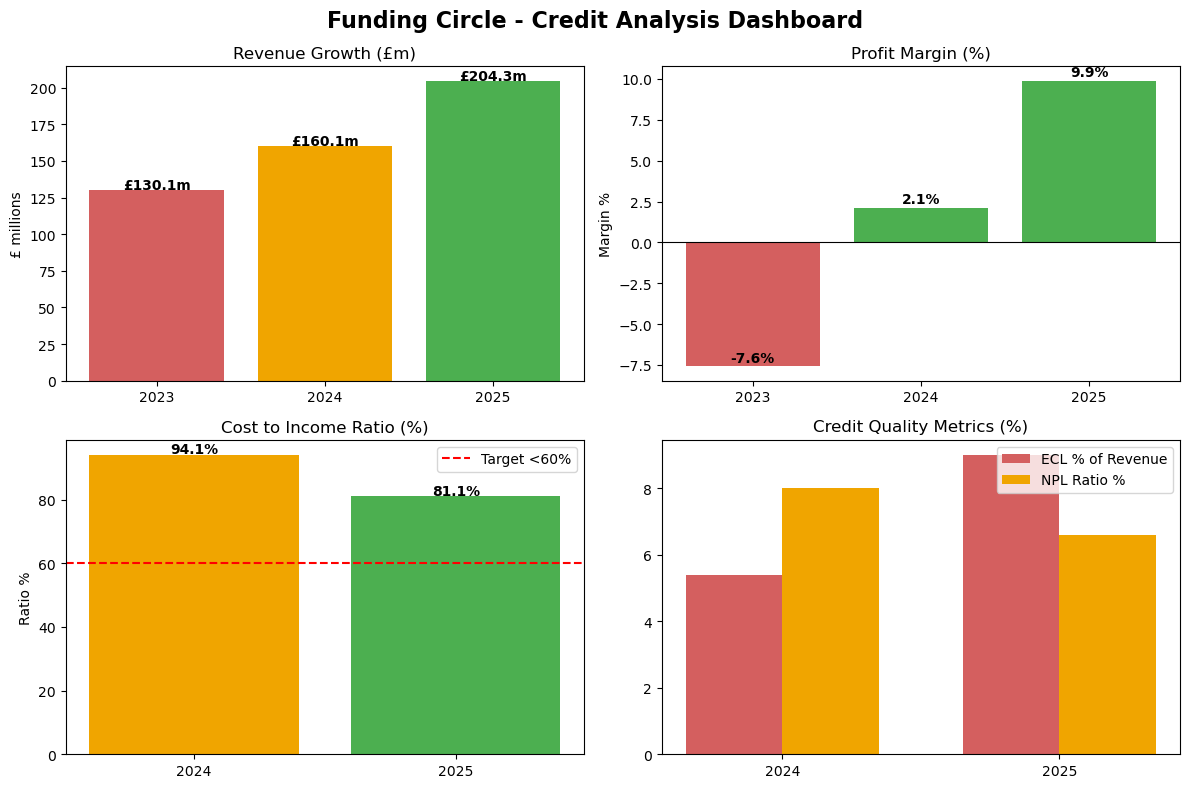

Dashboard saved successfully


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Funding Circle - Credit Analysis Dashboard', 
             fontsize=16, fontweight='bold')

years = ['2023', '2024', '2025']

# Chart 1 - Revenue and Profit Margin
ax1 = axes[0, 0]
revenue = [130.1, 160.1, 204.3]
ax1.bar(years, revenue, color=['#d45f5f', '#f0a500', '#4caf50'])
ax1.set_title('Revenue Growth (£m)')
ax1.set_ylabel('£ millions')
for i, v in enumerate(revenue):
    ax1.text(i, v + 1, f'£{v}m', ha='center', fontweight='bold')

# Chart 2 - Profit Margin
ax2 = axes[0, 1]
margins = [-7.6, 2.1, 9.9]
colors = ['#d45f5f' if x < 0 else '#4caf50' for x in margins]
ax2.bar(years, margins, color=colors)
ax2.set_title('Profit Margin (%)')
ax2.set_ylabel('Margin %')
ax2.axhline(y=0, color='black', linewidth=0.8)
for i, v in enumerate(margins):
    ax2.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 3 - Cost to Income
ax3 = axes[1, 0]
cti = [94.1, 81.1]
ax3.bar(['2024', '2025'], cti, color=['#f0a500', '#4caf50'])
ax3.set_title('Cost to Income Ratio (%)')
ax3.set_ylabel('Ratio %')
ax3.axhline(y=60, color='red', linewidth=1.5, 
            linestyle='--', label='Target <60%')
ax3.legend()
for i, v in enumerate(cti):
    ax3.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Chart 4 - ECL vs NPL
ax4 = axes[1, 1]
ecl = [5.4, 9.0]
npl = [8.0, 6.6]
x = np.arange(2)
width = 0.35
ax4.bar(x - width/2, ecl, width, label='ECL % of Revenue', 
        color='#d45f5f')
ax4.bar(x + width/2, npl, width, label='NPL Ratio %', 
        color='#f0a500')
ax4.set_title('Credit Quality Metrics (%)')
ax4.set_xticks(x)
ax4.set_xticklabels(['2024', '2025'])
ax4.legend()

plt.tight_layout()

# Save the chart
chart_path = r"C:\Users\DELL\Desktop\FundingCircle_CreditAnalysis\credit_dashboard.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved successfully")

In [5]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf

# Funding Circle ticker on London Stock Exchange
fc = yf.Ticker("FCH.L")

# Pull income statement and balance sheet
income = fc.financials
balance = fc.balance_sheet

print("INCOME STATEMENT")
print(income)
print("\nBALANCE SHEET")
print(balance)

INCOME STATEMENT
                                                      2025-12-31  \
Tax Effect Of Unusual Items                        -2.500000e+04   
Tax Rate For Calcs                                  2.500000e-01   
Normalized EBITDA                                   3.150000e+07   
Total Unusual Items                                -1.000000e+05   
Total Unusual Items Excluding Goodwill             -1.000000e+05   
Net Income From Continuing Operation Net Minori...  4.600000e+07   
Reconciled Depreciation                             1.100000e+07   
Reconciled Cost Of Revenue                          6.010000e+07   
EBITDA                                              3.140000e+07   
EBIT                                                2.040000e+07   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income              

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Extract key metrics from yfinance data (convert to £millions)
def get_metric(df, row_name):
    if row_name in df.index:
        return df.loc[row_name] / 1_000_000
    return None

years = ['2023-12-31', '2024-12-31', '2025-12-31']

# Pull the rows we need
revenue      = get_metric(income, 'Total Revenue')
pretax       = get_metric(income, 'Pretax Income')
op_expense   = get_metric(income, 'Operating Expense')
equity       = get_metric(balance, 'Stockholders Equity')

# Build clean summary table
summary = pd.DataFrame(index=['2023', '2024', '2025'])

for yr, col in zip(['2023', '2024', '2025'], 
                   ['2023-12-31', '2024-12-31', '2025-12-31']):
    summary.loc[yr, 'Revenue (£m)']       = round(revenue[col], 1) if col in revenue.index else None
    summary.loc[yr, 'Pretax Income (£m)'] = round(pretax[col], 1)  if col in pretax.index  else None
    summary.loc[yr, 'Op Expense (£m)']    = round(op_expense[col], 1) if col in op_expense.index else None
    summary.loc[yr, 'Equity (£m)']        = round(equity[col], 1)  if col in equity.index   else None

# Calculate ratios
summary['Profit Margin %']   = round(summary['Pretax Income (£m)'] / summary['Revenue (£m)'] * 100, 1)
summary['Cost-to-Income %']  = round(summary['Op Expense (£m)']    / summary['Revenue (£m)'] * 100, 1)

print("FUNDING CIRCLE — AUTO-PULLED RATIO TABLE")
print("="*60)
print(summary.to_string())

FUNDING CIRCLE — AUTO-PULLED RATIO TABLE
      Revenue (£m)  Pretax Income (£m)  Op Expense (£m)  Equity (£m)  Profit Margin %  Cost-to-Income %
2023         129.7                -9.9             71.4        246.8             -7.6              55.1
2024         161.7                 0.8            105.1        216.5              0.5              65.0
2025         222.5                20.3            142.0        228.4              9.1              63.8


In [4]:
# Multi-company screener
companies = {
    'Funding Circle': 'FCH.L',
    'Close Brothers':  'CBG.L',
    'Paragon Banking': 'PAG.L',
    'OSB Group':       'OSB.L',
    'Virgin Money':    'VMUK.L'
}

results = []

for name, ticker in companies.items():
    try:
        t = yf.Ticker(ticker)
        inc = t.financials
        bal = t.balance_sheet
        
        # Get 2024 data (most recent full year for all)
        rev  = inc.loc['Total Revenue', '2024-12-31']    / 1e6 if '2024-12-31' in inc.columns else None
        pbt  = inc.loc['Pretax Income', '2024-12-31']    / 1e6 if '2024-12-31' in inc.columns else None
        opex = inc.loc['Operating Expense', '2024-12-31']/ 1e6 if '2024-12-31' in inc.columns else None
        eq   = bal.loc['Stockholders Equity', '2024-12-31']/1e6 if '2024-12-31' in bal.columns else None

        pm   = round(pbt / rev * 100, 1) if rev and pbt else None
        cti  = round(opex / rev * 100, 1) if rev and opex else None
        roe  = round(pbt / eq * 100, 1)  if eq and pbt else None

        results.append({
            'Company': name,
            'Revenue £m': round(rev, 1) if rev else None,
            'Pretax Income £m': round(pbt, 1) if pbt else None,
            'Profit Margin %': pm,
            'Cost-to-Income %': cti,
            'ROE %': roe
        })
        print(f"✓ {name} pulled successfully")
    except Exception as e:
        print(f"✗ {name} failed: {e}")

screener = pd.DataFrame(results).set_index('Company')
print("\nMULTI-COMPANY CREDIT SCREENER — 2024")
print("="*70)
print(screener.to_string())

✓ Funding Circle pulled successfully
✓ Close Brothers pulled successfully
✓ Paragon Banking pulled successfully
✓ OSB Group pulled successfully
✓ Virgin Money pulled successfully

MULTI-COMPANY CREDIT SCREENER — 2024
                 Revenue £m  Pretax Income £m  Profit Margin %  Cost-to-Income %  ROE %
Company                                                                                
Funding Circle        161.7               0.8              0.5              65.0    0.4
Close Brothers          NaN               NaN              NaN               NaN    NaN
Paragon Banking         NaN               NaN              NaN               NaN    NaN
OSB Group             664.9             418.1             62.9              38.9   18.8
Virgin Money            NaN               NaN              NaN               NaN    NaN


In [5]:
def get_val(df, row, possible_dates):
    for d in possible_dates:
        if row in df.index and d in df.columns:
            val = df.loc[row, d]
            if not pd.isna(val):
                return val / 1e6
    return None

companies = {
    'Funding Circle': 'FCH.L',
    'Close Brothers':  'CBG.L',
    'Paragon Banking': 'PAG.L',
    'OSB Group':       'OSB.L',
    'Virgin Money':    'VMUK.L'
}

# Try multiple possible year-end dates
date_options = ['2024-12-31', '2024-07-31', '2024-09-30', '2024-06-30', '2023-12-31']

results = []

for name, ticker in companies.items():
    try:
        t   = yf.Ticker(ticker)
        inc = t.financials
        bal = t.balance_sheet

        rev  = get_val(inc, 'Total Revenue',      date_options)
        pbt  = get_val(inc, 'Pretax Income',       date_options)
        opex = get_val(inc, 'Operating Expense',   date_options)
        eq   = get_val(bal, 'Stockholders Equity', date_options)

        pm  = round(pbt  / rev * 100, 1) if rev and pbt  else None
        cti = round(opex / rev * 100, 1) if rev and opex else None
        roe = round(pbt  / eq  * 100, 1) if eq  and pbt  else None

        results.append({
            'Company':           name,
            'Revenue £m':        round(rev, 1) if rev else None,
            'Pretax Income £m':  round(pbt, 1) if pbt else None,
            'Profit Margin %':   pm,
            'Cost-to-Income %':  cti,
            'ROE %':             roe
        })
        print(f"✓ {name}")
    except Exception as e:
        print(f"✗ {name}: {e}")

screener = pd.DataFrame(results).set_index('Company')
print("\nMULTI-COMPANY CREDIT SCREENER")
print("="*70)
print(screener.to_string())

✓ Funding Circle
✓ Close Brothers
✓ Paragon Banking
✓ OSB Group
✓ Virgin Money

MULTI-COMPANY CREDIT SCREENER
                 Revenue £m  Pretax Income £m  Profit Margin %  Cost-to-Income %  ROE %
Company                                                                                
Funding Circle        161.7               0.8              0.5              65.0    0.4
Close Brothers        793.0             132.7             16.7              67.6    7.2
Paragon Banking       481.7             253.8             52.7              42.2   17.9
OSB Group             664.9             418.1             62.9              38.9   18.8
Virgin Money            NaN               NaN              NaN               NaN    NaN


In [6]:
# Virgin Money delisted - replace with Aldermore parent and Metro Bank
companies_v2 = {
    'Funding Circle': 'FCH.L',
    'Close Brothers':  'CBG.L',
    'Paragon Banking': 'PAG.L',
    'OSB Group':       'OSB.L',
    'Metro Bank':      'MTRO.L'
}

results = []

for name, ticker in companies_v2.items():
    try:
        t   = yf.Ticker(ticker)
        inc = t.financials
        bal = t.balance_sheet

        rev  = get_val(inc, 'Total Revenue',      date_options)
        pbt  = get_val(inc, 'Pretax Income',       date_options)
        opex = get_val(inc, 'Operating Expense',   date_options)
        eq   = get_val(bal, 'Stockholders Equity', date_options)

        pm  = round(pbt  / rev * 100, 1) if rev and pbt  else None
        cti = round(opex / rev * 100, 1) if rev and opex else None
        roe = round(pbt  / eq  * 100, 1) if eq  and pbt  else None

        results.append({
            'Company':          name,
            'Revenue £m':       round(rev, 1) if rev else None,
            'Pretax Income £m': round(pbt, 1) if pbt else None,
            'Profit Margin %':  pm,
            'Cost-to-Income %': cti,
            'ROE %':            roe
        })
        print(f"✓ {name}")
    except Exception as e:
        print(f"✗ {name}: {e}")

screener = pd.DataFrame(results).set_index('Company')
print("\nMULTI-COMPANY CREDIT SCREENER")
print("="*70)
print(screener.to_string())

✓ Funding Circle
✓ Close Brothers
✓ Paragon Banking
✓ OSB Group
✓ Metro Bank

MULTI-COMPANY CREDIT SCREENER
                 Revenue £m  Pretax Income £m  Profit Margin %  Cost-to-Income %  ROE %
Company                                                                                
Funding Circle        161.7               0.8              0.5              65.0    0.4
Close Brothers        793.0             132.7             16.7              67.6    7.2
Paragon Banking       481.7             253.8             52.7              42.2   17.9
OSB Group             664.9             418.1             62.9              38.9   18.8
Metro Bank            405.3            -212.1            -52.3             139.7  -17.9


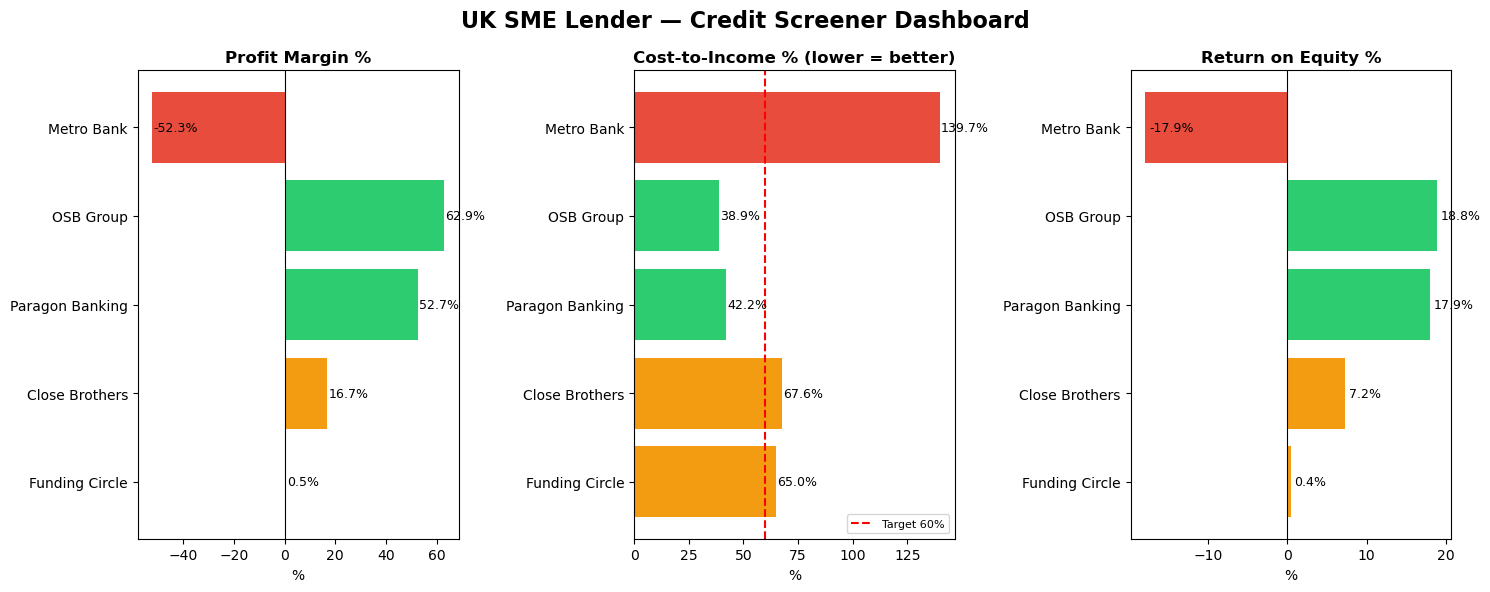

Dashboard saved.


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('UK SME Lender — Credit Screener Dashboard', 
             fontsize=16, fontweight='bold')

companies_list = screener.index.tolist()
colors = ['#e74c3c' if x < 0 else '#2ecc71' if x > 30 else '#f39c12' 
          for x in screener['Profit Margin %'].fillna(0)]

# Chart 1 — Profit Margin
ax1 = axes[0]
bars = ax1.barh(companies_list, screener['Profit Margin %'].fillna(0), color=colors)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_title('Profit Margin %', fontweight='bold')
ax1.set_xlabel('%')
for bar, val in zip(bars, screener['Profit Margin %'].fillna(0)):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

# Chart 2 — Cost to Income
ax2 = axes[1]
cti_colors = ['#e74c3c' if x > 80 else '#f39c12' if x > 60 else '#2ecc71' 
              for x in screener['Cost-to-Income %'].fillna(0)]
bars2 = ax2.barh(companies_list, screener['Cost-to-Income %'].fillna(0), color=cti_colors)
ax2.axvline(x=60, color='red', linewidth=1.5, linestyle='--', label='Target 60%')
ax2.set_title('Cost-to-Income % (lower = better)', fontweight='bold')
ax2.set_xlabel('%')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, screener['Cost-to-Income %'].fillna(0)):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

# Chart 3 — ROE
ax3 = axes[2]
roe_colors = ['#e74c3c' if x < 0 else '#2ecc71' if x > 15 else '#f39c12' 
              for x in screener['ROE %'].fillna(0)]
bars3 = ax3.barh(companies_list, screener['ROE %'].fillna(0), color=roe_colors)
ax3.axvline(x=0, color='black', linewidth=0.8)
ax3.set_title('Return on Equity %', fontweight='bold')
ax3.set_xlabel('%')
for bar, val in zip(bars3, screener['ROE %'].fillna(0)):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
chart_path = r"C:\Users\DELL\Desktop\FundingCircle_CreditAnalysis\screener_dashboard.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [8]:
# Save screener table to Excel
screener.to_excel(r"C:\Users\DELL\Desktop\FundingCircle_CreditAnalysis\screener_results.xlsx")
print("All files saved. Project 2 complete.")
print("\nFiles in your folder:")
print("1. funding_circle_data.xlsx — raw data")
print("2. ratio_analysis.xlsx — FC ratio table")
print("3. credit_dashboard.png — FC charts (Project 1)")
print("4. screener_results.xlsx — 5 company comparison")
print("5. screener_dashboard.png — comparison dashboard (Project 2)")

All files saved. Project 2 complete.

Files in your folder:
1. funding_circle_data.xlsx — raw data
2. ratio_analysis.xlsx — FC ratio table
3. credit_dashboard.png — FC charts (Project 1)
4. screener_results.xlsx — 5 company comparison
5. screener_dashboard.png — comparison dashboard (Project 2)
